# User-Cohort Dynamics

Describe changes in account-creation cohorts and user characteristics across Stack Exchange sites. The current monthly export is grouped by account creation month and therefore does **not** measure monthly active users.

In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt

def root():
    for p in [Path.cwd(),*Path.cwd().parents]:
        q=p/'stack_exchange_analysis'
        if (p/'database').exists(): return p
        if (q/'database').exists(): return q
    raise FileNotFoundError
PROJECT_ROOT=root(); DATA_DIR=PROJECT_ROOT/'database'; ANALYSIS_DIR=PROJECT_ROOT/'analysis'; ANALYSIS_DIR.mkdir(exist_ok=True); sys.path.insert(0,str(PROJECT_ROOT/'src'))
from analysis_utils import read_csv_flexible, save_figure

users=read_csv_flexible(DATA_DIR/'user-metrics-by-site-by-month-all-time.csv'); month_col=next((c for c in users if c.lower() in {'creationmonth','month','date'}),None); site_col=next((c for c in users if c.lower()=='site'),None)
if month_col is None or site_col is None: raise ValueError(f'Expected Site and CreationMonth-like columns, got {list(users.columns)}')
users[month_col]=pd.to_datetime(users[month_col],errors='coerce')
for c in users.columns:
    if c not in {month_col,site_col}: users[c]=pd.to_numeric(users[c],errors='coerce')
print(users[[site_col,month_col]].dropna().agg({month_col:['min','max']}))

    CreationMonth
min    2008-07-01
max    2026-05-01


## Stack Overflow registration cohorts

,Site,CreationMonth,UsersCount,DistinctNetworkAccounts,TotalReputation,AvgReputation,MinReputation,MaxReputation,StdReputation,TotalProfileViews,...,MinDaysSinceLastAccess,MaxDaysSinceLastAccess,UsersWithWebsite,UsersWithoutWebsite,UsersWithAboutMe,UsersWithoutAboutMe,UsersWithProfileImage,UsersWithoutProfileImage,UsersWithNetworkAccount,UsersWithoutNetworkAccount
104,StackOverflow,2026-01-01,162957,162957,179929,1.104150,1,707,3.450931,24687,...,5,141,4768,158189,5581,157376,0,162957,162957,0
83,StackOverflow,2026-02-01,139253,139253,151370,1.087014,1,190,2.521545,15807,...,5,110,4073,135180,4533,134720,0,139253,139253,0
62,StackOverflow,2026-03-01,134319,134318,143997,1.072052,1,171,2.227706,19537,...,5,82,4387,129932,5012,129307,0,134319,134319,0
41,StackOverflow,2026-04-01,111951,111951,119761,1.069763,1,162,2.157698,20147,...,5,51,4135,107816,6344,105607,0,111951,111951,0
20,StackOverflow,2026-05-01,54121,54121,58024,1.072116,1,129,2.197675,8482,...,5,21,2200,51921,2363,51758,0,54121,54121,0


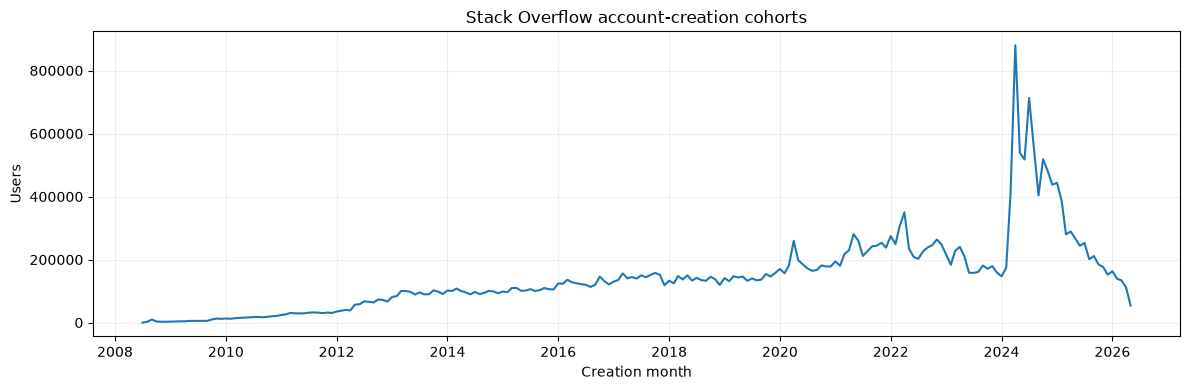

In [2]:
so=users[users[site_col].astype(str).str.contains('StackOverflow',case=False,na=False)].sort_values(month_col).copy(); display(so.tail())
if not so.empty and 'UsersCount' in so:
    fig,ax=plt.subplots(figsize=(12,4)); ax.plot(so[month_col],so['UsersCount']); ax.set(title='Stack Overflow account-creation cohorts',xlabel='Creation month',ylabel='Users'); ax.grid(alpha=.2); save_figure(fig,ANALYSIS_DIR/'users_stackoverflow_cohorts.png'); plt.show()

## Cohort characteristics

,CreationMonth,AvgReputation,AvgProfileViews,AvgUpVotesCast,AvgDownVotesCast,AvgDaysSinceLastAccess,AvgAccountAgeDays
503,2024-06-01,1.233534,1.831908,0.024281,0.003494,622.686746,703.963343
482,2024-07-01,1.155377,1.482566,0.008757,0.000917,630.332501,679.798278
461,2024-08-01,1.174941,1.141727,0.012861,0.001488,581.682031,642.468846
440,2024-09-01,1.203967,0.353407,0.014425,0.002853,534.442368,612.529713
419,2024-10-01,1.160123,0.151334,0.013931,0.003314,504.860378,583.434477
398,2024-11-01,1.174801,0.114574,0.016812,0.000687,485.763326,552.245957
377,2024-12-01,1.156968,0.097911,0.025928,0.000827,464.312047,522.995211
356,2025-01-01,1.136916,0.098218,0.014489,0.000746,437.757115,490.672643
335,2025-02-01,1.138937,0.102639,0.013328,0.000504,413.757738,461.388525
314,2025-03-01,1.164955,0.150959,0.015117,0.000939,389.452956,432.229748


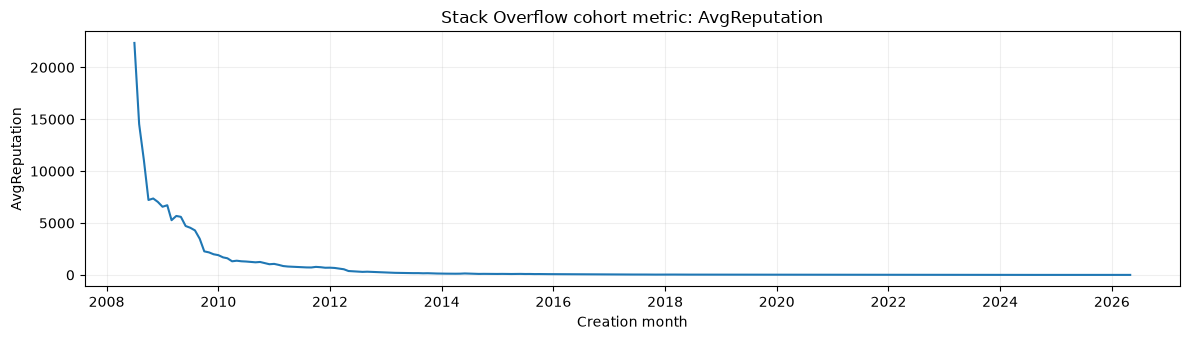

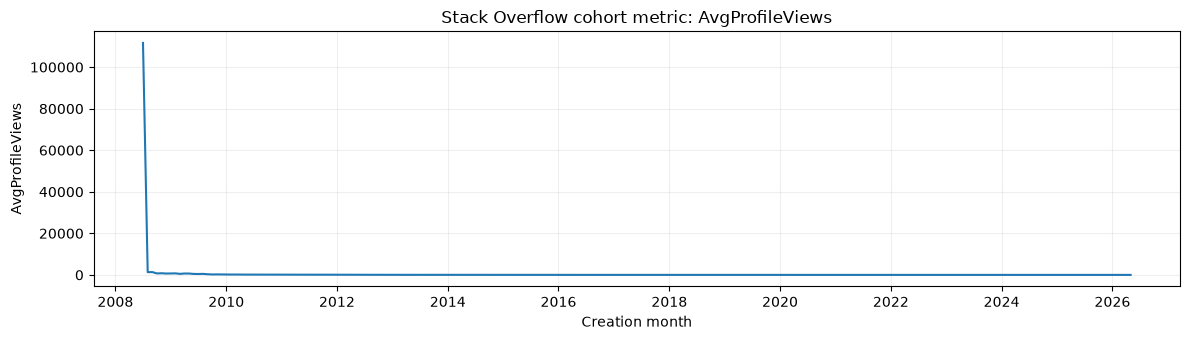

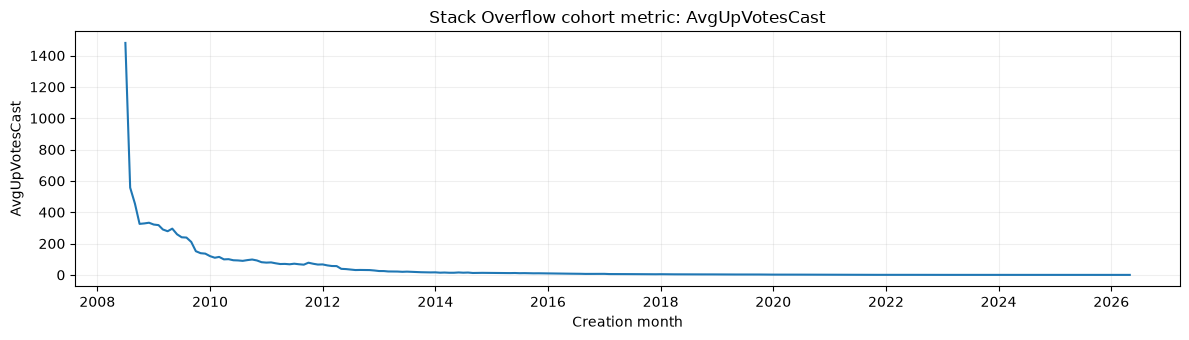

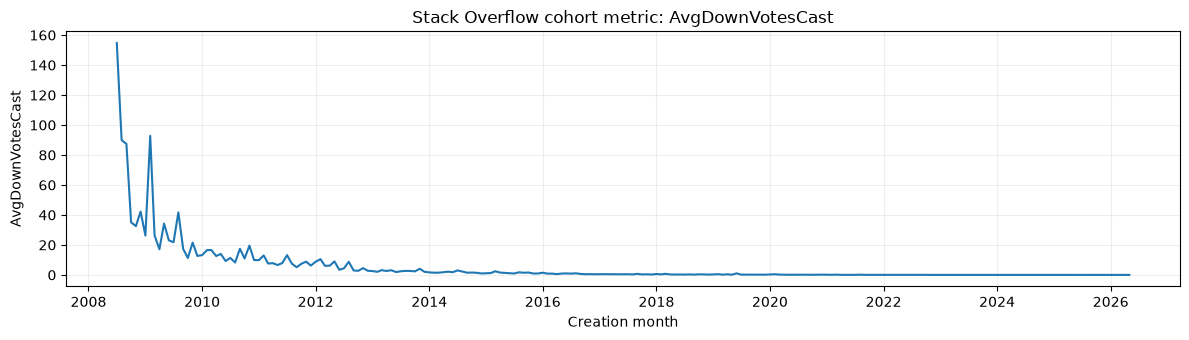

In [3]:
metrics=[c for c in ['AvgReputation','AvgProfileViews','AvgUpVotesCast','AvgDownVotesCast','AvgDaysSinceLastAccess','AvgAccountAgeDays'] if c in so]
if metrics: display(so[[month_col]+metrics].tail(24))
for metric in metrics[:4]:
    fig,ax=plt.subplots(figsize=(12,3.5)); ax.plot(so[month_col],so[metric]); ax.set(title=f'Stack Overflow cohort metric: {metric}',xlabel='Creation month',ylabel=metric); ax.grid(alpha=.2); save_figure(fig,ANALYSIS_DIR/f'users_{metric.lower()}.png'); plt.show()

## Cross-site registration trajectories

In [4]:
if 'UsersCount' in users:
    p=users.pivot_table(index=month_col,columns=site_col,values='UsersCount',aggfunc='sum').sort_index()
    def norm(s):
        pos=s[s>0].dropna(); b=pos.iloc[:12].mean() if len(pos)>=6 else np.nan; return 100*s/b if pd.notna(b) and b else s*np.nan
    idx=p.apply(norm); display(idx.dropna(how='all').iloc[-1].sort_values().rename('latest_registration_index').to_frame())

,latest_registration_index
Site,
StackExchange.Cseducators,8.875740
StackExchange.Genai,12.798375
StackExchange.Cstheory,14.583811
StackExchange.Computergraphics,14.842579
StackExchange.Quantumcomputing,23.989899
StackExchange.Scicomp,28.654971
StackExchange.Ai,30.560000
StackExchange.Cs,42.308499
StackExchange.Matheducators,57.232952


## Static site-level metrics

In [5]:
static=read_csv_flexible(DATA_DIR/'user-static-metrics-by-several-site-all-time.csv'); display(static.sort_values('UsersCount',ascending=False).head(25) if 'UsersCount' in static else static.head(25))

,Site,UsersCount,DistinctNetworkAccounts,TotalReputation,AvgReputation,MinReputation,MaxReputation,TotalProfileViews,AvgProfileViews,MinProfileViews,...,MaxNetVotesCast,UpvoteDownvoteRatio,UsersWithWebsite,UsersWithoutWebsite,UsersWithAboutMe,UsersWithoutAboutMe,UsersWithProfileImage,UsersWithoutProfileImage,UsersWithNetworkAccount,UsersWithoutNetworkAccount
0,StackOverflow,31196878,31183438,2050173188,65.717255,1,1527241,329737478,10.569567,0,...,113777,8.089699,2540007,28656871,3500679,27696199,0,31196878,31183602,13276
1,StackExchange.Math,1595235,1591099,117934470,73.929214,1,638235,30876876,19.355691,0,...,113513,8.007997,72347,1522888,147516,1447719,0,1595235,1591115,4120
2,StackExchange.Mathoverflow,507555,506297,26393828,52.001907,1,249512,17346645,34.176877,0,...,51183,13.995977,292863,214692,316038,191517,0,507555,506302,1253
3,StackExchange.Physics,493491,491663,26382729,53.461419,1,375625,13788260,27.940246,0,...,31958,6.027254,33647,459844,66730,426761,0,493491,491666,1825
4,StackExchange.Stats,433655,432134,25551575,58.921435,1,347294,10634872,24.523808,0,...,130967,27.779027,34129,399526,62374,371281,0,433655,432136,1519
5,StackExchange.Tex,381794,380141,39381625,103.148884,1,1264539,7462372,19.545546,0,...,82902,96.830884,36124,345670,61802,319992,0,381794,380146,1648
6,StackExchange.Datascience,164987,164060,7053587,42.752380,1,30058,2307478,13.985817,0,...,4793,13.538009,21524,143463,40632,124355,0,164987,164067,920
7,StackExchange.Cs,157055,155678,9393839,59.812416,1,281345,2911735,18.539588,0,...,20038,8.900469,25518,131537,45214,111841,0,157055,155679,1376
8,StackExchange.Ai,88953,88323,3362883,37.805167,1,43701,687861,7.732859,0,...,3416,8.606992,13256,75697,23561,65392,0,88953,88327,626
9,StackExchange.Engineering,69655,69259,2153016,30.909712,1,24395,1455225,20.891896,0,...,2361,9.597913,5967,63688,12730,56925,0,69655,69259,396


## Takeaways
These data support investigation of entry and cohort composition. Active askers, active answerers, first-time askers, and retention require new activity-based SQL exports before participation mechanisms can be evaluated.